# **xG - Goles Esperados - Validación del Modelo con Regresión Logística**

Carga de artefactos finales


- `modelo_xg_logistico_12vars.joblib`
- `metadata_modelo_xg_logistico_12vars.json`
- `df_validacion_modelo_xg_12vars.csv`
- `df_coeficientes_modelo_xg_12vars.csv`
- `df_importancia_modelo_xg_12vars.csv`

La base `df_validacion_modelo_xg_12vars.csv` ya contiene las variables finales transformadas.


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

In [2]:
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [3]:
ruta_processed = Path("..") / "data" / "processed"

In [4]:
with open(ruta_processed / "metadata_modelo_xg_logistico_12vars.json", "r", encoding="utf-8") as archivo:
    metadata_modelo = json.load(archivo)

modelo_logistico = joblib.load(ruta_processed / "modelo_xg_logistico_12vars.joblib")

df_validacion_modelo_xg = pd.read_csv(ruta_processed / "df_validacion_modelo_xg_12vars.csv")

df_coeficientes_modelo = pd.read_csv(ruta_processed / "df_coeficientes_modelo_xg_12vars.csv")

df_importancia = pd.read_csv(ruta_processed / "df_importancia_modelo_xg_12vars.csv")

columnas_modelo_final = metadata_modelo["columnas_modelo_final"]
umbral = metadata_modelo["umbral_operativo"]

print("Modelo:", metadata_modelo["nombre_modelo"])
print("Umbral operativo fijo:", umbral)
print("Variables finales:", len(columnas_modelo_final))
print("Base validación:", df_validacion_modelo_xg.shape)

Modelo: modelo_xg_logistico_12vars
Umbral operativo fijo: 0.211
Variables finales: 12
Base validación: (63482, 27)


Se separan los tres datasets y se aplica el modelo cargado.

In [5]:
df_train_validacion = df_validacion_modelo_xg[df_validacion_modelo_xg["dataset"] == "train"].copy().reset_index(drop=True)

df_test_validacion = df_validacion_modelo_xg[df_validacion_modelo_xg["dataset"] == "test"].copy().reset_index(drop=True)

df_aplicacion_validacion = df_validacion_modelo_xg[df_validacion_modelo_xg["dataset"] == "aplicacion"].copy().reset_index(drop=True)

X_train_final = df_train_validacion[columnas_modelo_final].copy()
X_test_final = df_test_validacion[columnas_modelo_final].copy()
X_aplicacion_final = df_aplicacion_validacion[columnas_modelo_final].copy()

y_train = df_train_validacion["gol"].copy()
y_test = df_test_validacion["gol"].copy()
y_aplicacion = df_aplicacion_validacion["gol"].copy()

prob_train = modelo_logistico.predict_proba(X_train_final)[:, 1]
prob_test = modelo_logistico.predict_proba(X_test_final)[:, 1]
prob_aplicacion = modelo_logistico.predict_proba(X_aplicacion_final)[:, 1]

print("Train:", X_train_final.shape, y_train.shape, round(prob_train.sum(), 2))
print("Test:", X_test_final.shape, y_test.shape, round(prob_test.sum(), 2))
print("Aplicación:", X_aplicacion_final.shape, y_aplicacion.shape, round(prob_aplicacion.sum(), 2))

Train: (47082, 12) (47082,) 4992.71
Test: (15890, 12) (15890,) 1673.99
Aplicación: (510, 12) (510,) 58.16


In [6]:
datasets_validacion = {
    "train": {"df": df_train_validacion,"X": X_train_final,"y": y_train.reset_index(drop=True),"prob": pd.Series(prob_train).reset_index(drop=True)},
    "test": {"df": df_test_validacion,"X": X_test_final,"y": y_test.reset_index(drop=True),"prob": pd.Series(prob_test).reset_index(drop=True)},
    "aplicacion": {"df": df_aplicacion_validacion,"X": X_aplicacion_final,"y": y_aplicacion.reset_index(drop=True),"prob": pd.Series(prob_aplicacion).reset_index(drop=True)}}

for nombre_dataset, contenido in datasets_validacion.items():
    print(nombre_dataset, "filas:", len(contenido["y"]))

train filas: 47082
test filas: 15890
aplicacion filas: 510


Cálculo de métricas para el modelo como estimador de probabilidad/xG. Train - Test - Aplicación

In [7]:
metricas_prob = []

for nombre_dataset, contenido in datasets_validacion.items():

    y_real = contenido["y"]
    probabilidad = contenido["prob"]

    metricas_prob.append({
            "dataset": nombre_dataset,
            "tiros": len(y_real),
            "goles_reales": int(y_real.sum()),
            "xg_estimado": probabilidad.sum().round(1),
            "diferencia_goles_xg": (probabilidad.sum() - int(y_real.sum())).round(1),
            "tasa_gol_real": y_real.mean(),
            "xg_promedio": probabilidad.mean(),
            "auc_roc": roc_auc_score(y_real, probabilidad),
            "average_precision": average_precision_score(y_real, probabilidad),
            "log_loss": log_loss(y_real, probabilidad),
            "brier_score": brier_score_loss(y_real, probabilidad)})

df_metricas_prob = pd.DataFrame(metricas_prob)

df_metricas_prob

,dataset,tiros,goles_reales,xg_estimado,diferencia_goles_xg,tasa_gol_real,xg_promedio,auc_roc,average_precision,log_loss,brier_score
0,train,47082,4943,4992.7,49.7,0.104987,0.106043,0.792730,0.390615,0.274927,0.078371
1,test,15890,1688,1674.0,-14.0,0.106230,0.105349,0.794530,0.402797,0.275339,0.078591
2,aplicacion,510,57,58.2,1.2,0.111765,0.114031,0.764746,0.375080,0.294889,0.083970


### Validación de la clasificación con el umbral elegido

In [8]:
def evaluar_umbral_fijo(y_real, probabilidad, umbral, nombre_dataset):

    prediccion = (probabilidad >= umbral).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_real,
        prediccion,
        labels=[0, 1]
    ).ravel()

    especificidad = tn / (tn + fp)

    resultado = {
        "dataset": nombre_dataset,
        "umbral": umbral,
        "predichos_gol": int(prediccion.sum()),
        "goles_reales": int(y_real.sum()),
        "diferencia_abs": abs(int(prediccion.sum()) - int(y_real.sum())),
        "accuracy": accuracy_score(y_real, prediccion),
        "balanced_accuracy": balanced_accuracy_score(y_real, prediccion),
        "precision": precision_score(y_real, prediccion, zero_division=0),
        "recall": recall_score(y_real, prediccion, zero_division=0),
        "specificity": especificidad,
        "f1": f1_score(y_real, prediccion, zero_division=0),
        "mcc": matthews_corrcoef(y_real, prediccion),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    }

    return resultado

In [9]:
metricas_umbral = []

for nombre_dataset, contenido in datasets_validacion.items():

    resultado = evaluar_umbral_fijo(
        y_real=contenido["y"],
        probabilidad=contenido["prob"],
        umbral=umbral,
        nombre_dataset=nombre_dataset
    )

    metricas_umbral.append(resultado)

df_metricas_umbral = pd.DataFrame(metricas_umbral)

df_metricas_umbral

,dataset,umbral,predichos_gol,goles_reales,diferencia_abs,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,tp,fp,tn,fn
0,train,0.211,4962,4943,19,0.872754,0.662301,0.394397,0.395913,0.928688,0.395154,0.324053,1957,3005,39134,2986
1,test,0.211,1643,1688,45,0.873946,0.662215,0.404139,0.393365,0.931066,0.398679,0.328324,664,979,13223,1024
2,aplicacion,0.211,59,57,2,0.858824,0.652144,0.372881,0.385965,0.918322,0.379310,0.299748,22,37,416,35


## • Matrices de confusión

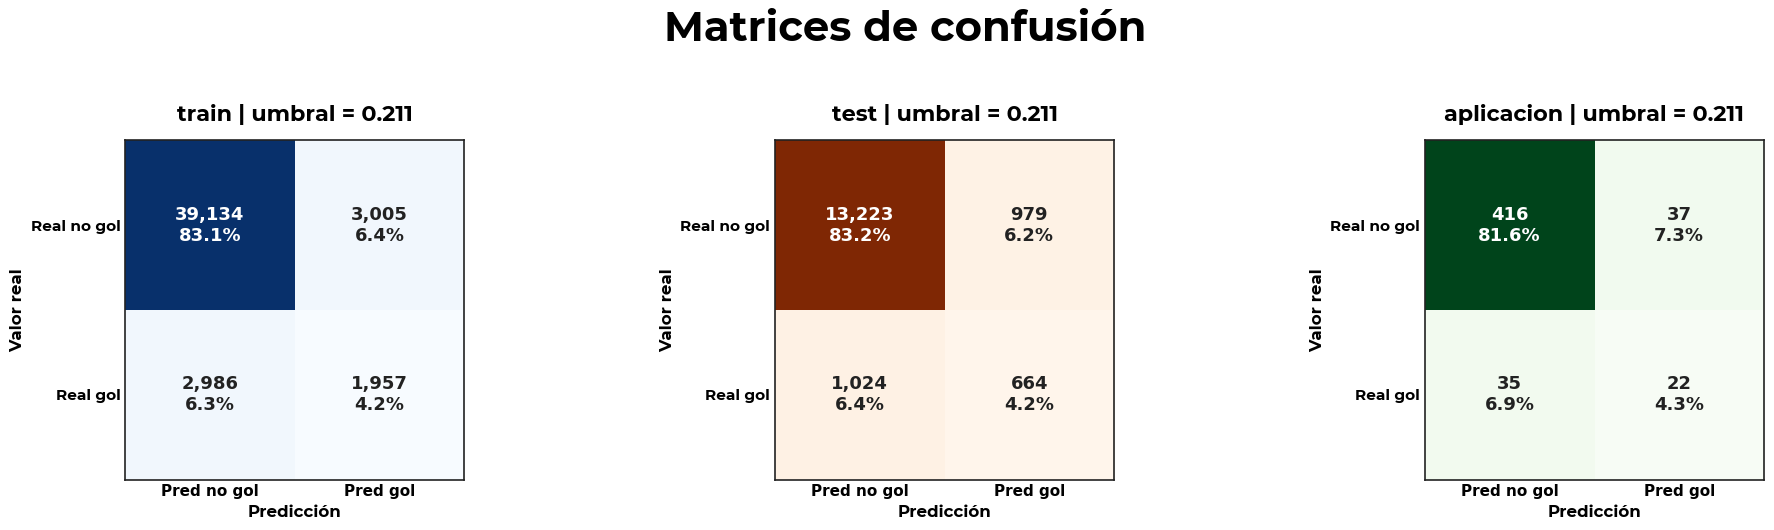

In [10]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

lista_colores = ["Blues", "Oranges", "Greens"]

for ax, nombre_dataset, escala_color in zip(
    axes,
    ["train", "test", "aplicacion"],
    lista_colores
):

    y_real = datasets_validacion[nombre_dataset]["y"]
    probabilidad = datasets_validacion[nombre_dataset]["prob"]

    prediccion = (probabilidad >= umbral).astype(int)

    matriz = confusion_matrix(
        y_real,
        prediccion,
        labels=[0, 1]
    )

    total = matriz.sum()

    imagen = ax.imshow(
        matriz,
        cmap=escala_color
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        ["Pred no gol", "Pred gol"],
        fontsize=11,
        fontweight="bold"
    )

    ax.set_yticklabels(
        ["Real no gol", "Real gol"],
        fontsize=11,
        fontname="Montserrat",
        fontweight="bold"
    )

    valor_maximo = matriz.max()

    for fila in range(2):
        for columna in range(2):

            valor = matriz[fila, columna]
            porcentaje = valor / total

            if valor > valor_maximo * 0.50:
                color_texto = "white"
            else:
                color_texto = "#222222"

            ax.text(
                columna,
                fila,
                f"{valor:,}\n{porcentaje:.1%}",
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=color_texto
            )

    ax.set_title(
        nombre_dataset + " | umbral = " + str(round(umbral, 3)),
        fontsize=16,
        fontname="Montserrat",
        fontweight="bold",
        pad=14
    )

    ax.set_xlabel(
        "Predicción",
        fontsize=12,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Valor real",
        fontsize=12,
        fontname="Montserrat",
        fontweight="bold"
    )

    for borde in ax.spines.values():
        borde.set_visible(True)
        borde.set_linewidth(1.2)
        borde.set_color("#222222")

    ax.tick_params(axis="both", length=0)

plt.suptitle(
    "Matrices de confusión",
    fontsize=30,
    fontname="Montserrat",
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()

## • Curvas ROC

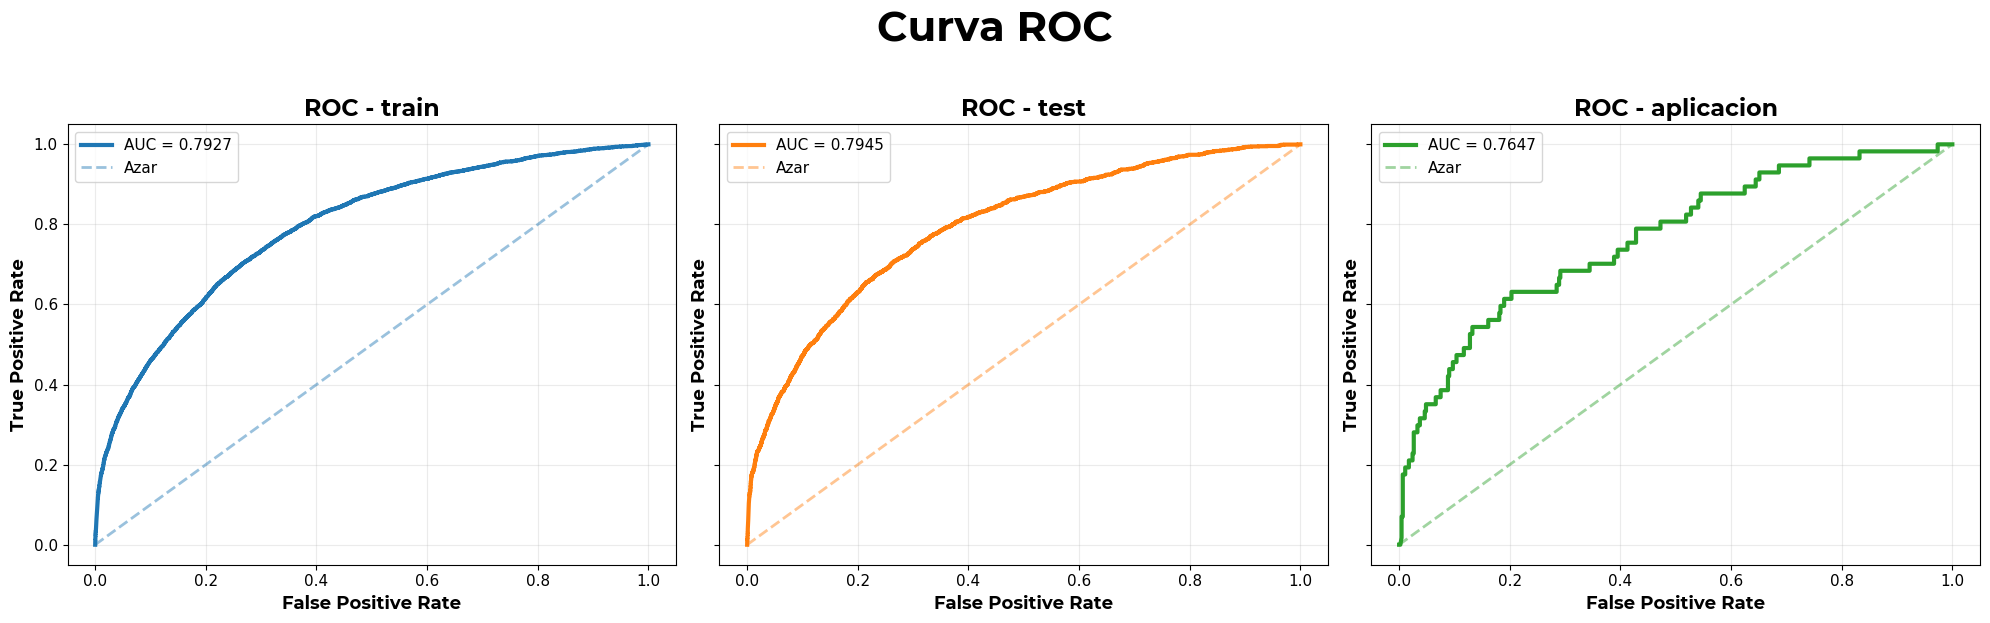

In [11]:
lista_colores = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    contenido = datasets_validacion[nombre_dataset]

    y_real = contenido["y"]
    probabilidad = contenido["prob"]

    fpr, tpr, _ = roc_curve(y_real, probabilidad)
    auc = roc_auc_score(y_real, probabilidad)

    ax = axes[i]

    ax.plot(
        fpr,
        tpr,
        linewidth=3,
        color=lista_colores[i],
        label="AUC = " + str(round(auc, 4))
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        color=lista_colores[i],
        alpha=0.45,
        label="Azar"
    )

    ax.set_title(
        "ROC - " + nombre_dataset,
        fontsize=17,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_xlabel(
        "False Positive Rate",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_ylabel(
        "True Positive Rate",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.tick_params(axis="both", labelsize=11)

    ax.legend(
        fontsize=11,
        frameon=True
    )

    ax.grid(alpha=0.25)

plt.suptitle(
    "Curva ROC",
    fontsize=30,
    fontname="Montserrat",
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

## • Curvas Precision-Recall

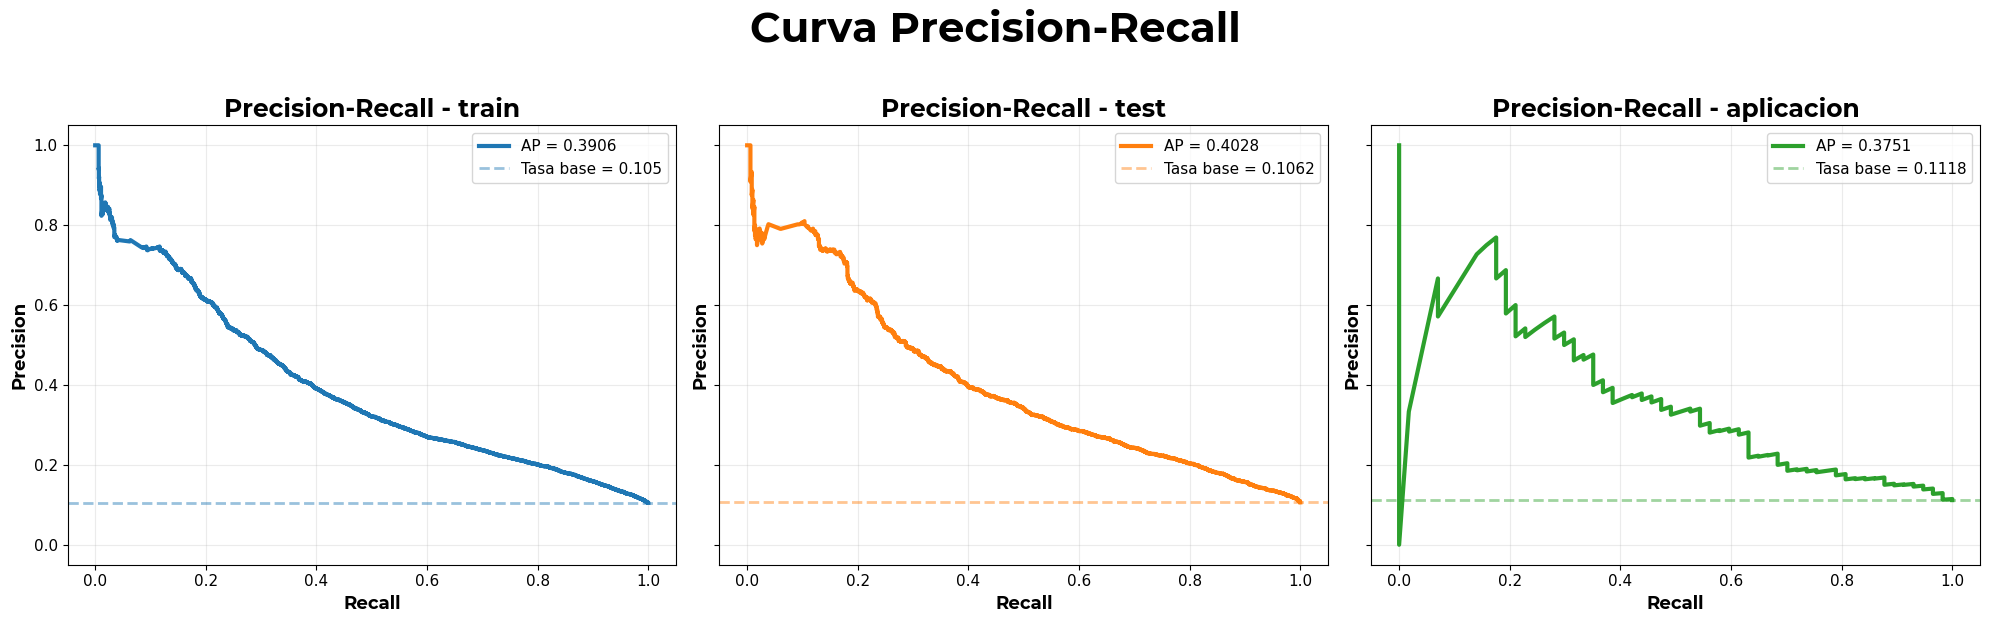

In [12]:
lista_colores = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots( 1, 3, figsize=(20, 6), sharex=True, sharey=True )

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    contenido = datasets_validacion[nombre_dataset]

    y_real = contenido["y"]
    probabilidad = contenido["prob"]

    precision, recall, _ = precision_recall_curve(y_real, probabilidad)
    average_precision = average_precision_score(y_real, probabilidad)

    ax = axes[i]

    ax.plot( recall, precision, linewidth=3, color=lista_colores[i], label="AP = " + str(round(average_precision, 4)))

    ax.axhline( y_real.mean(), linestyle="--", linewidth=2, color=lista_colores[i], alpha=0.45, label="Tasa base = " + str(round(y_real.mean(), 4))
    )

    ax.set_title( "Precision-Recall - " + nombre_dataset, fontsize=18, fontname="Montserrat", fontweight="bold" )

    ax.set_xlabel( "Recall", fontsize=13, fontname="Montserrat", fontweight="bold" )

    ax.set_ylabel( "Precision", fontname="Montserrat", fontsize=13, fontweight="bold" )

    ax.tick_params(axis="both", labelsize=11)

    ax.legend(fontsize=11,frameon=True)

    ax.grid(alpha=0.25)

plt.suptitle( "Curva Precision-Recall", fontsize=30, fontweight="bold", fontname="Montserrat", y=1.03 )

plt.tight_layout()
plt.show()

## • KS

In [13]:
def calcular_ks(y_real, probabilidad, nombre_dataset):

    df_ks = pd.DataFrame()

    df_ks["gol"] = y_real.reset_index(drop=True)
    df_ks["xg"] = probabilidad.reset_index(drop=True)

    df_ks = df_ks.sort_values(
        "xg",
        ascending=False
    ).reset_index(drop=True)

    df_ks["no_gol"] = 1 - df_ks["gol"]

    df_ks["acum_gol"] = df_ks["gol"].cumsum() / df_ks["gol"].sum()
    df_ks["acum_no_gol"] = df_ks["no_gol"].cumsum() / df_ks["no_gol"].sum()

    df_ks["ks"] = abs(df_ks["acum_gol"] - df_ks["acum_no_gol"])
    df_ks["porcentaje_muestra"] = (df_ks.index + 1) / len(df_ks)
    df_ks["dataset"] = nombre_dataset

    return df_ks

In [14]:
lista_ks = []
resumen_ks = []

for nombre_dataset, contenido in datasets_validacion.items():

    df_ks_dataset = calcular_ks(
        y_real=contenido["y"],
        probabilidad=contenido["prob"],
        nombre_dataset=nombre_dataset
    )

    lista_ks.append(df_ks_dataset)

    fila_max = df_ks_dataset.loc[df_ks_dataset["ks"].idxmax()]

    resumen_ks.append(
        {
            "dataset": nombre_dataset,
            "ks_max": fila_max["ks"],
            "porcentaje_muestra_max_ks": fila_max["porcentaje_muestra"]
        }
    )

df_ks_total = pd.concat(lista_ks, ignore_index=True)
df_resumen_ks = pd.DataFrame(resumen_ks)

df_resumen_ks

,dataset,ks_max,porcentaje_muestra_max_ks
0,train,0.436276,0.315981
1,test,0.442483,0.312461
2,aplicacion,0.428488,0.250980


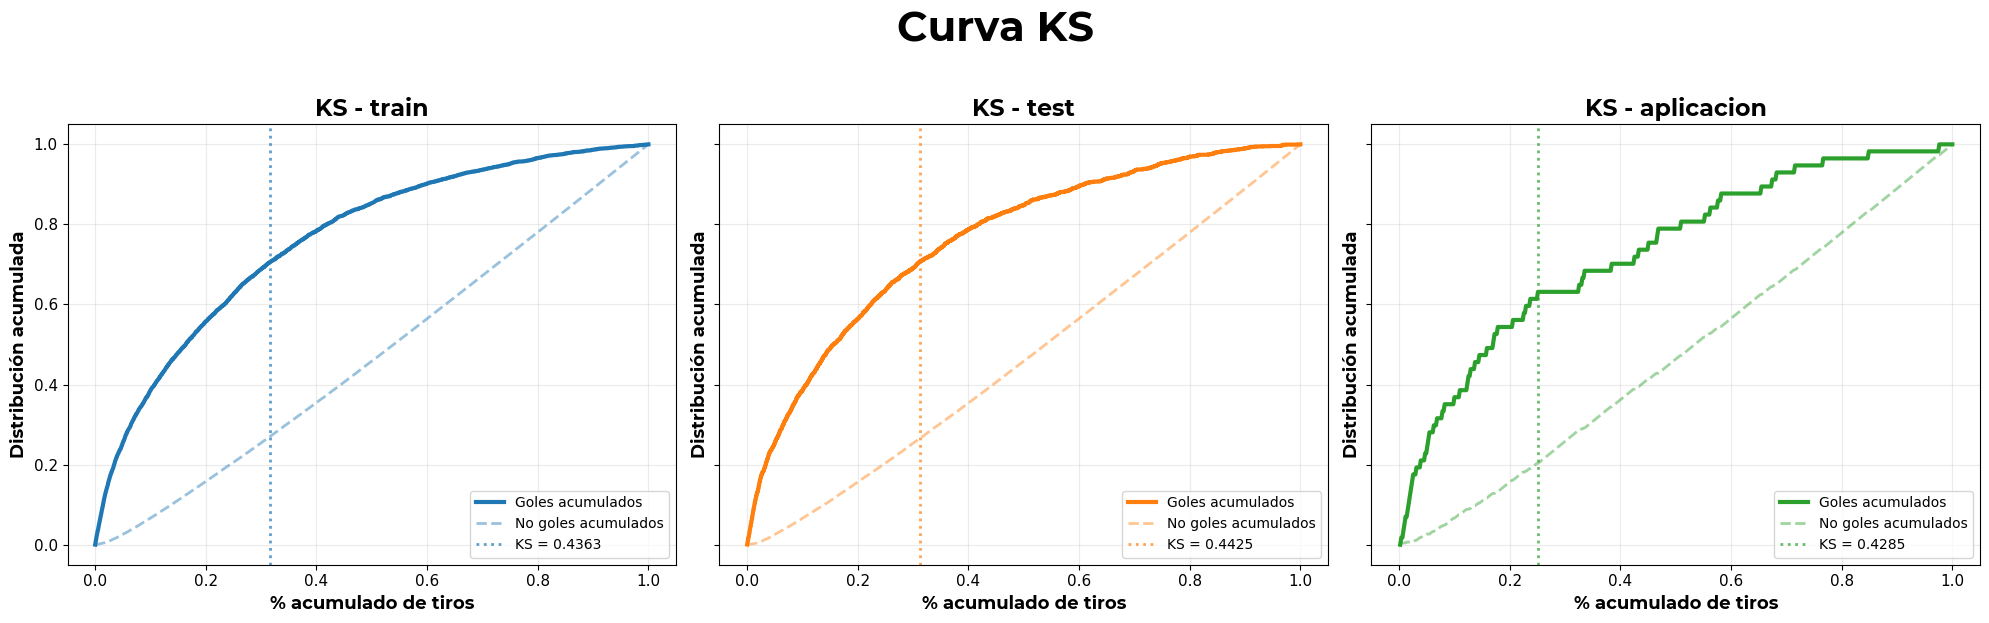

In [15]:
fig, axes = plt.subplots( 1, 3, figsize=(20, 6), sharex=True, sharey=True )

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    contenido = datasets_validacion[nombre_dataset]

    y_real = contenido["y"].reset_index(drop=True)
    probabilidad = pd.Series(contenido["prob"]).reset_index(drop=True)

    df_ks = pd.DataFrame()
    df_ks["gol"] = y_real
    df_ks["xg"] = probabilidad

    df_ks = df_ks.sort_values(
        "xg",
        ascending=False
    ).reset_index(drop=True)

    df_ks["no_gol"] = 1 - df_ks["gol"]

    df_ks["acum_gol"] = df_ks["gol"].cumsum() / df_ks["gol"].sum()
    df_ks["acum_no_gol"] = df_ks["no_gol"].cumsum() / df_ks["no_gol"].sum()

    df_ks["ks"] = abs(df_ks["acum_gol"] - df_ks["acum_no_gol"])
    df_ks["porcentaje_muestra"] = (df_ks.index + 1) / len(df_ks)

    ks_max = df_ks["ks"].max()
    punto_ks = df_ks[df_ks["ks"] == ks_max].iloc[0]

    ax = axes[i]

    ax.plot(
        df_ks["porcentaje_muestra"],
        df_ks["acum_gol"],
        linewidth=3,
        color=lista_colores[i],
        label="Goles acumulados")

    ax.plot(
        df_ks["porcentaje_muestra"],
        df_ks["acum_no_gol"],
        linestyle="--",
        linewidth=2,
        color=lista_colores[i],
        alpha=0.45,
        label="No goles acumulados")

    ax.axvline(
        punto_ks["porcentaje_muestra"],
        linestyle=":",
        linewidth=2,
        color=lista_colores[i],
        alpha=0.70,
        label="KS = " + str(round(ks_max, 4)))

    ax.set_title(
        "KS - " + nombre_dataset,
        fontsize=17,
        fontname="Montserrat",
        fontweight="bold")

    ax.set_xlabel(
        "% acumulado de tiros",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold")

    ax.set_ylabel(
        "Distribución acumulada",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold")

    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, frameon=True)
    ax.grid(alpha=0.25)

plt.suptitle( "Curva KS", fontsize=30, fontname="Montserrat", fontweight="bold", y=1.03 )

plt.tight_layout()
plt.show()

## • Calibración por deciles

Se compara xG promedio contra tasa real de gol en cada decil de score.

In [16]:
def calcular_calibracion_deciles(y_real, probabilidad, nombre_dataset):

    df_calibracion = pd.DataFrame()

    df_calibracion["gol"] = y_real.reset_index(drop=True)
    df_calibracion["xg"] = probabilidad.reset_index(drop=True)

    df_calibracion["decil_xg"] = pd.qcut(
        df_calibracion["xg"],
        q=10,
        labels=False,
        duplicates="drop"
    )

    df_calibracion["decil_xg"] = df_calibracion["decil_xg"].max() - df_calibracion["decil_xg"] + 1
    df_calibracion["dataset"] = nombre_dataset

    df_resumen = df_calibracion.groupby(
        ["dataset", "decil_xg"]
    ).agg(
        tiros=("gol", "count"),
        goles=("gol", "sum"),
        xg_promedio=("xg", "mean"),
        xg_total=("xg", "sum"),
        tasa_gol_real=("gol", "mean")
    ).reset_index()

    df_resumen = df_resumen.sort_values(["dataset", "decil_xg"])

    return df_resumen

In [17]:
lista_calibracion = []

for nombre_dataset, contenido in datasets_validacion.items():

    df_calibracion_dataset = calcular_calibracion_deciles(
        y_real=contenido["y"],
        probabilidad=contenido["prob"],
        nombre_dataset=nombre_dataset
    )

    lista_calibracion.append(df_calibracion_dataset)

df_calibracion_resumen = pd.concat(lista_calibracion, ignore_index=True)

df_calibracion_resumen

,dataset,decil_xg,tiros,goles,xg_promedio,xg_total,tasa_gol_real
0,train,1,4709,1906,0.388006,1827.122269,0.404757
1,train,2,4708,852,0.175134,824.528543,0.180969
2,train,3,4708,647,0.126909,597.487458,0.137426
3,train,4,4708,473,0.099262,467.324701,0.100467
4,train,5,4708,340,0.079398,373.807913,0.072218
5,train,6,4708,242,0.063442,298.684092,0.051402
6,train,7,4708,169,0.049865,234.765873,0.035896
7,train,8,4708,145,0.037504,176.568221,0.030799
8,train,9,4708,102,0.026512,124.817250,0.021665
9,train,10,4709,67,0.014356,67.600917,0.014228


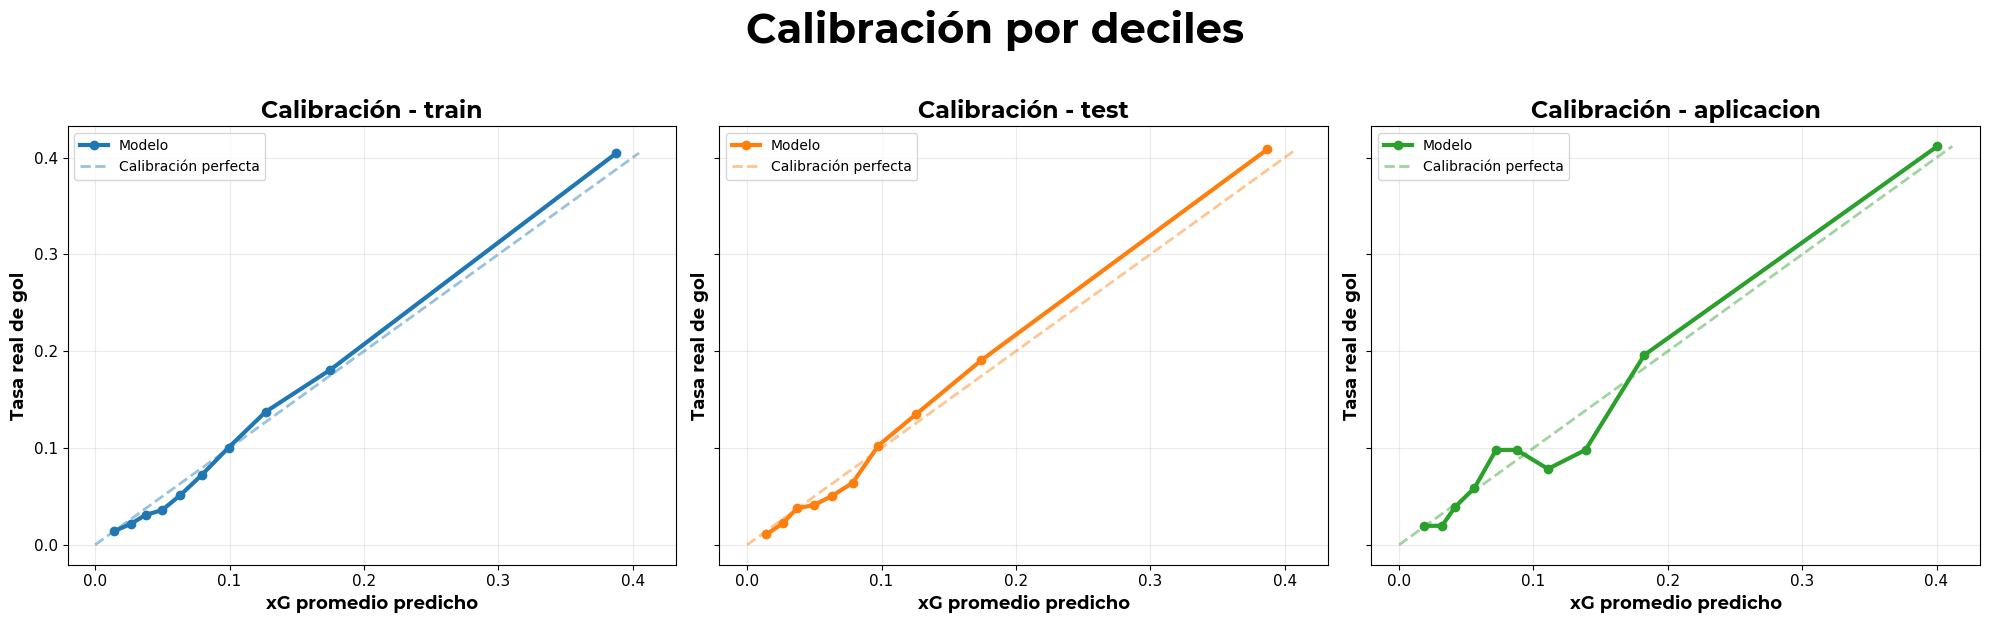

In [18]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    contenido = datasets_validacion[nombre_dataset]

    y_real = contenido["y"].reset_index(drop=True)
    probabilidad = pd.Series(contenido["prob"]).reset_index(drop=True)

    df_calibracion = pd.DataFrame()
    df_calibracion["gol"] = y_real
    df_calibracion["xg"] = probabilidad

    df_calibracion["decil_xg"] = pd.qcut(
        df_calibracion["xg"],
        q=10,
        labels=False,
        duplicates="drop"
    )

    df_calibracion_resumen = df_calibracion.groupby(
        "decil_xg"
    ).agg(
        tiros=("gol", "count"),
        goles=("gol", "sum"),
        xg_promedio=("xg", "mean"),
        tasa_gol_real=("gol", "mean")
    ).reset_index()

    ax = axes[i]

    ax.plot(
        df_calibracion_resumen["xg_promedio"],
        df_calibracion_resumen["tasa_gol_real"],
        marker="o",
        linewidth=3,
        color=lista_colores[i],
        label="Modelo"
    )

    valor_maximo = max(
        df_calibracion_resumen["xg_promedio"].max(),
        df_calibracion_resumen["tasa_gol_real"].max()
    )

    ax.plot(
        [0, valor_maximo],
        [0, valor_maximo],
        linestyle="--",
        linewidth=2,
        color=lista_colores[i],
        alpha=0.45,
        label="Calibración perfecta"
    )

    ax.set_title(
        "Calibración - " + nombre_dataset,
        fontsize=17,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_xlabel(
        "xG promedio predicho",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Tasa real de gol",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, frameon=True)
    ax.grid(alpha=0.25)

plt.suptitle(
    "Calibración por deciles",
    fontsize=30,
    fontname="Montserrat",
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [19]:
lista_calibracion = []

for nombre_dataset, contenido in datasets_validacion.items():

    y_real = contenido["y"].reset_index(drop=True)
    probabilidad = pd.Series(contenido["prob"]).reset_index(drop=True)

    df_calibracion = pd.DataFrame()
    df_calibracion["gol"] = y_real
    df_calibracion["xg"] = probabilidad

    df_calibracion["decil_xg"] = pd.qcut(
        df_calibracion["xg"],
        q=10,
        labels=False,
        duplicates="drop"
    )

    df_calibracion["decil_xg"] = df_calibracion["decil_xg"].max() - df_calibracion["decil_xg"] + 1

    df_resumen = df_calibracion.groupby(
        "decil_xg"
    ).agg(
        tiros=("gol", "count"),
        goles=("gol", "sum"),
        xg_promedio=("xg", "mean"),
        xg_total=("xg", "sum"),
        tasa_gol_real=("gol", "mean")
    ).reset_index()

    df_resumen["dataset"] = nombre_dataset

    lista_calibracion.append(df_resumen)

df_calibracion_resumen = pd.concat(
    lista_calibracion,
    ignore_index=True
)

df_calibracion_resumen.head()

,decil_xg,tiros,goles,xg_promedio,xg_total,tasa_gol_real,dataset
0,1,4709,1906,0.388006,1827.122269,0.404757,train
1,2,4708,852,0.175134,824.528543,0.180969,train
2,3,4708,647,0.126909,597.487458,0.137426,train
3,4,4708,473,0.099262,467.324701,0.100467,train
4,5,4708,340,0.079398,373.807913,0.072218,train


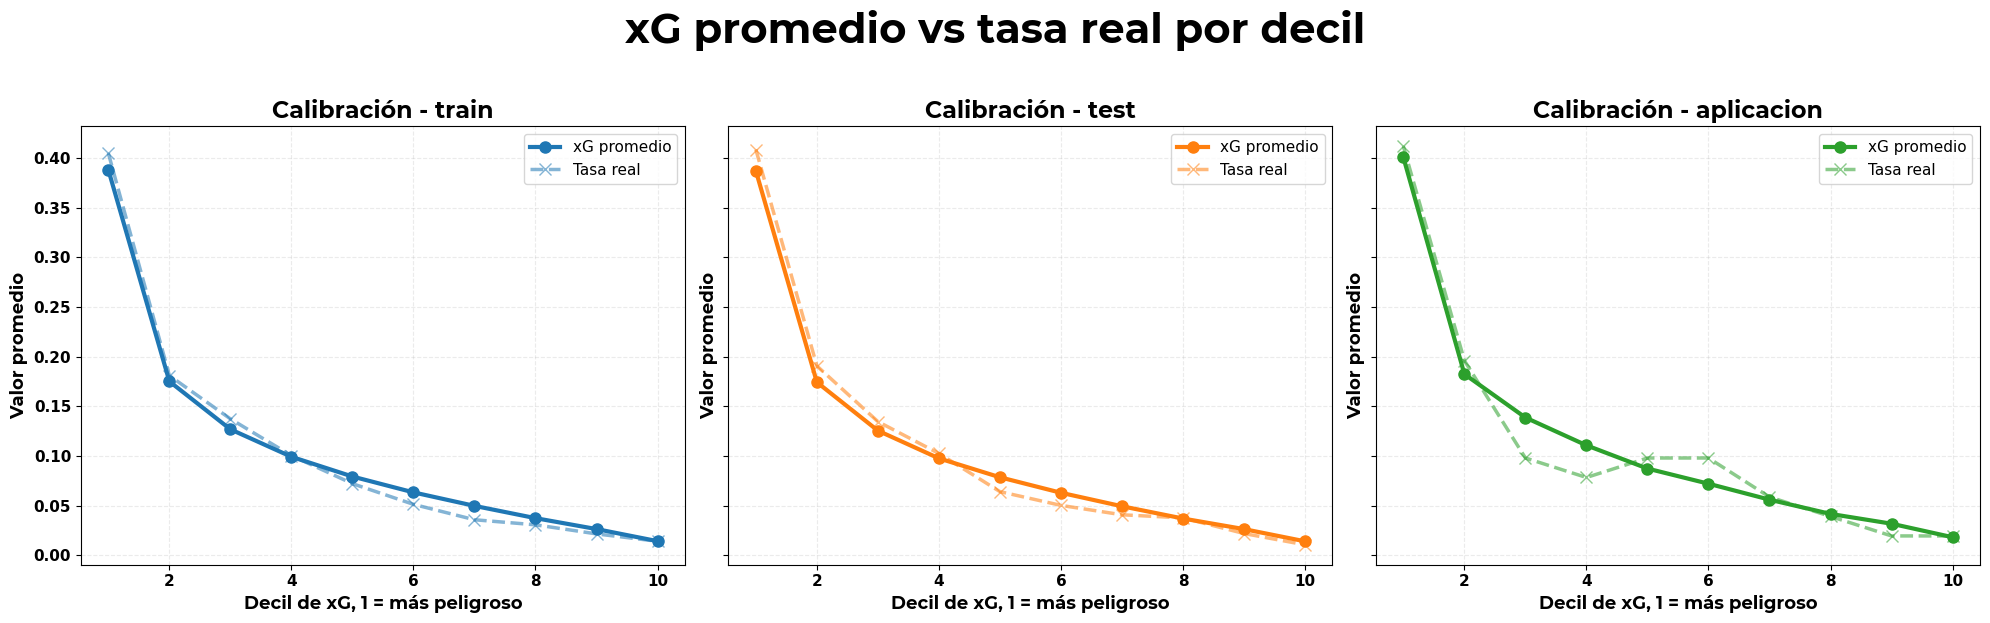

In [20]:
lista_colores = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    df_temp = df_calibracion_resumen[
        df_calibracion_resumen["dataset"] == nombre_dataset
    ].copy()

    ax = axes[i]

    ax.plot(
        df_temp["decil_xg"],
        df_temp["xg_promedio"],
        marker="o",
        markersize=8,
        linewidth=3,
        color=lista_colores[i],
        label="xG promedio"
    )

    ax.plot(
        df_temp["decil_xg"],
        df_temp["tasa_gol_real"],
        marker="x",
        markersize=9,
        linestyle="--",
        linewidth=2.5,
        color=lista_colores[i],
        alpha=0.55,
        label="Tasa real"
    )

    ax.set_title(
        "Calibración - " + nombre_dataset,
        fontsize=17,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_xlabel(
        "Decil de xG, 1 = más peligroso",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Valor promedio",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.tick_params(axis="both", labelsize=11)

    for etiqueta in ax.get_xticklabels():
        etiqueta.set_fontweight("bold")

    for etiqueta in ax.get_yticklabels():
        etiqueta.set_fontweight("bold")

    ax.grid(
        axis="both",
        linestyle="--",
        linewidth=0.8,
        alpha=0.25
    )

    ax.legend(
        fontsize=11,
        frameon=True
    )

plt.suptitle(
    "xG promedio vs tasa real por decil",
    fontsize=30,
    fontname="Montserrat",
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

## • Lift por decil

In [21]:
tasas_base = {}

for nombre_dataset, contenido in datasets_validacion.items():
    tasas_base[nombre_dataset] = contenido["y"].mean()

df_calibracion_resumen["tasa_base_dataset"] = df_calibracion_resumen["dataset"].map(tasas_base)

df_calibracion_resumen["lift"] = (
    df_calibracion_resumen["tasa_gol_real"] /
    df_calibracion_resumen["tasa_base_dataset"]
)

df_calibracion_resumen[
    ["dataset", "decil_xg", "tiros", "goles", "tasa_gol_real", "xg_promedio", "lift"]
]

,dataset,decil_xg,tiros,goles,tasa_gol_real,xg_promedio,lift
0,train,1,4709,1906,0.404757,0.388006,3.855303
1,train,2,4708,852,0.180969,0.175134,1.723723
2,train,3,4708,647,0.137426,0.126909,1.308977
3,train,4,4708,473,0.100467,0.099262,0.956949
4,train,5,4708,340,0.072218,0.079398,0.687871
5,train,6,4708,242,0.051402,0.063442,0.489602
6,train,7,4708,169,0.035896,0.049865,0.341912
7,train,8,4708,145,0.030799,0.037504,0.293357
8,train,9,4708,102,0.021665,0.026512,0.206361
9,train,10,4709,67,0.014228,0.014356,0.135522


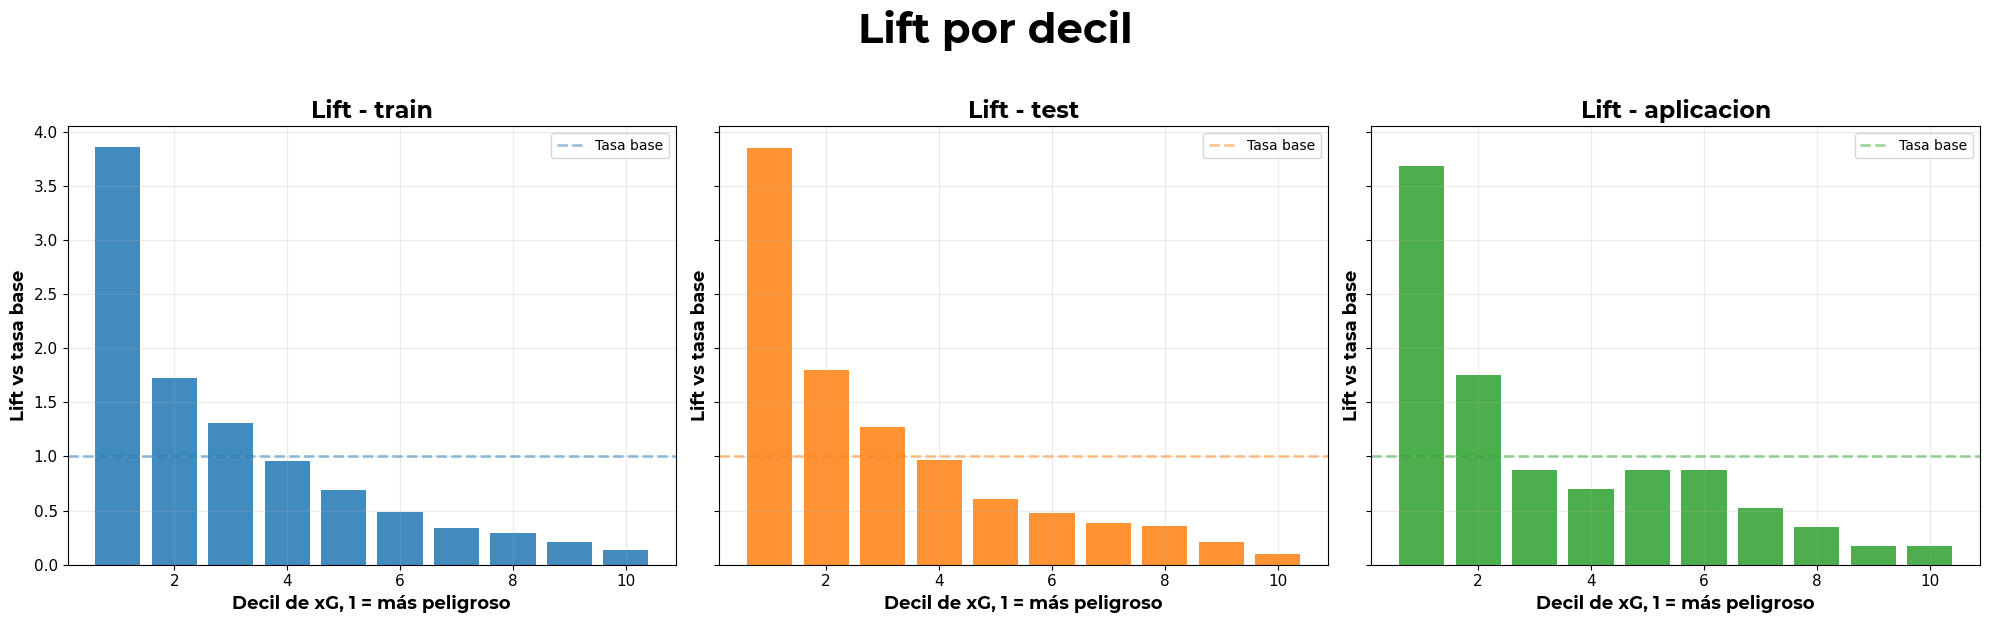

In [22]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    contenido = datasets_validacion[nombre_dataset]

    y_real = contenido["y"].reset_index(drop=True)
    probabilidad = pd.Series(contenido["prob"]).reset_index(drop=True)

    df_lift = pd.DataFrame()
    df_lift["gol"] = y_real
    df_lift["xg"] = probabilidad

    df_lift["decil_xg"] = pd.qcut(
        df_lift["xg"],
        q=10,
        labels=False,
        duplicates="drop"
    )

    df_lift["decil_xg"] = df_lift["decil_xg"].max() - df_lift["decil_xg"] + 1

    df_lift_resumen = df_lift.groupby(
        "decil_xg"
    ).agg(
        tiros=("gol", "count"),
        goles=("gol", "sum"),
        tasa_gol_real=("gol", "mean")
    ).reset_index()

    tasa_base = y_real.mean()

    df_lift_resumen["lift"] = df_lift_resumen["tasa_gol_real"] / tasa_base

    ax = axes[i]

    ax.bar(
        df_lift_resumen["decil_xg"],
        df_lift_resumen["lift"],
        color=lista_colores[i],
        alpha=0.85
    )

    ax.axhline(
        1,
        linestyle="--",
        linewidth=2,
        color=lista_colores[i],
        alpha=0.45,
        label="Tasa base"
    )

    ax.set_title(
        "Lift - " + nombre_dataset,
        fontsize=17,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_xlabel(
        "Decil de xG, 1 = más peligroso",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Lift vs tasa base",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, frameon=True)
    ax.grid(alpha=0.25)

plt.suptitle(
    "Lift por decil",
    fontsize=30,
    fontname="Montserrat",
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

## • Cumulative gains

In [23]:
lista_gains = []

for nombre_dataset in ["train", "test", "aplicacion"]:

    df_temp = df_calibracion_resumen[
        df_calibracion_resumen["dataset"] == nombre_dataset
    ].copy()

    df_temp = df_temp.sort_values("decil_xg").copy()

    df_temp["tiros_acum"] = df_temp["tiros"].cumsum()
    df_temp["goles_acum"] = df_temp["goles"].cumsum()

    df_temp["pct_tiros_acum"] = df_temp["tiros_acum"] / df_temp["tiros"].sum()
    df_temp["pct_goles_acum"] = df_temp["goles_acum"] / df_temp["goles"].sum()

    lista_gains.append(df_temp)

df_gains_total = pd.concat(lista_gains, ignore_index=True)

df_gains_total[["dataset", "decil_xg", "pct_tiros_acum", "pct_goles_acum"]]

,dataset,decil_xg,pct_tiros_acum,pct_goles_acum
0,train,1,0.100017,0.385596
1,train,2,0.200013,0.557961
2,train,3,0.300008,0.688853
3,train,4,0.400004,0.784544
4,train,5,0.500000,0.853328
5,train,6,0.599996,0.902286
6,train,7,0.699992,0.936476
7,train,8,0.799987,0.965810
8,train,9,0.899983,0.986445
9,train,10,1.000000,1.000000


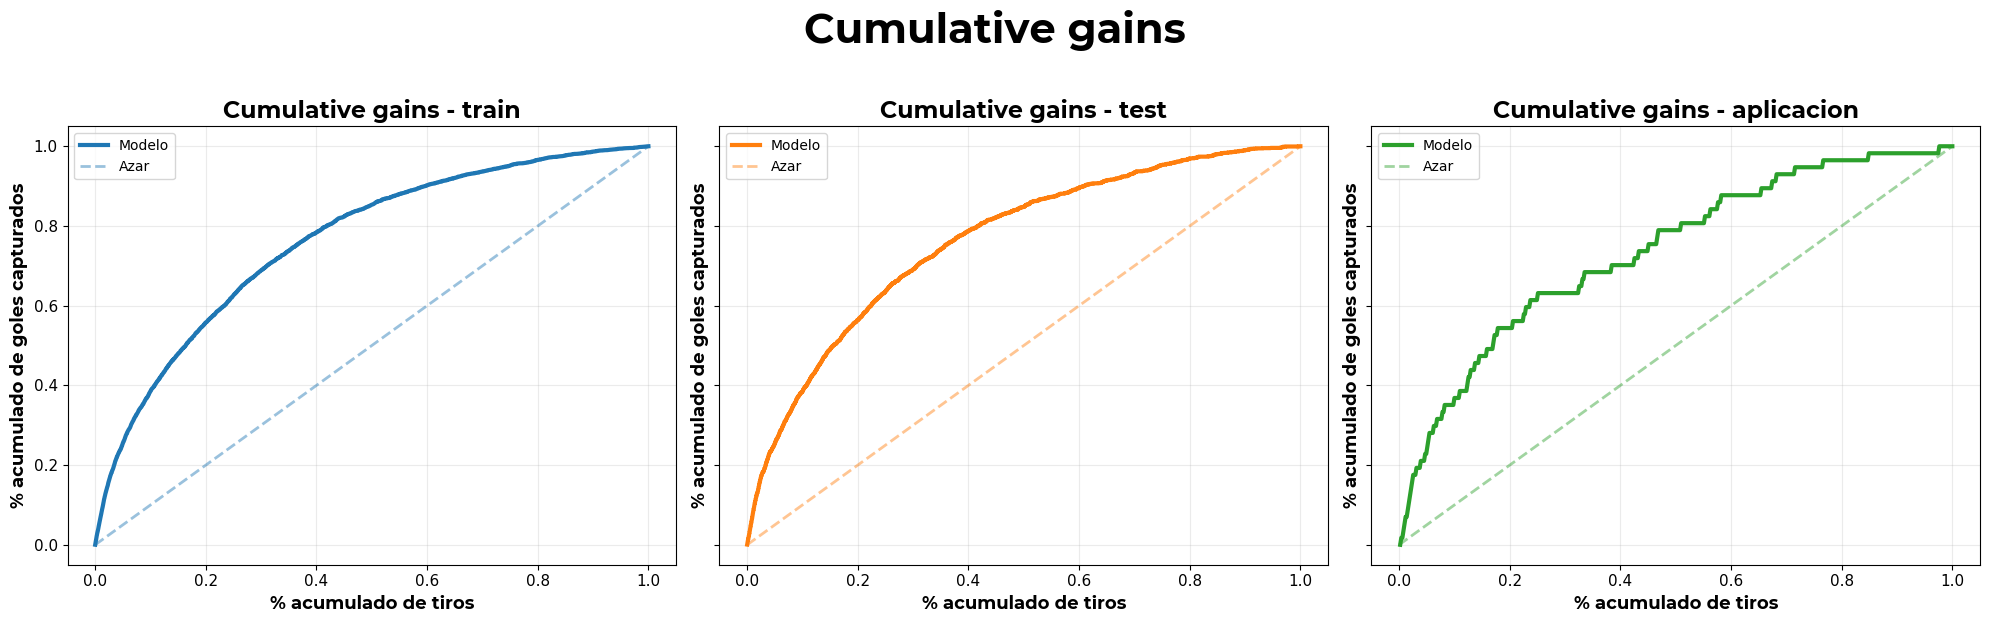

In [24]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    contenido = datasets_validacion[nombre_dataset]

    y_real = contenido["y"].reset_index(drop=True)
    probabilidad = pd.Series(contenido["prob"]).reset_index(drop=True)

    df_gains = pd.DataFrame()
    df_gains["gol"] = y_real
    df_gains["xg"] = probabilidad

    df_gains = df_gains.sort_values(
        "xg",
        ascending=False
    ).reset_index(drop=True)

    df_gains["tiros_acum"] = df_gains.index + 1
    df_gains["goles_acum"] = df_gains["gol"].cumsum()

    df_gains["pct_tiros_acum"] = df_gains["tiros_acum"] / len(df_gains)
    df_gains["pct_goles_acum"] = df_gains["goles_acum"] / df_gains["gol"].sum()

    ax = axes[i]

    ax.plot(
        df_gains["pct_tiros_acum"],
        df_gains["pct_goles_acum"],
        linewidth=3,
        color=lista_colores[i],
        label="Modelo"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        color=lista_colores[i],
        alpha=0.45,
        label="Azar"
    )

    ax.set_title(
        "Cumulative gains - " + nombre_dataset,
        fontsize=17,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_xlabel(
        "% acumulado de tiros",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_ylabel(
        "% acumulado de goles capturados",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.tick_params(axis="both", labelsize=11)
    ax.legend(fontsize=10, frameon=True)
    ax.grid(alpha=0.25)

plt.suptitle(
    "Cumulative gains",
    fontsize=30,
    fontname="Montserrat",
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

## • Distribución del xG según resultado del tiro

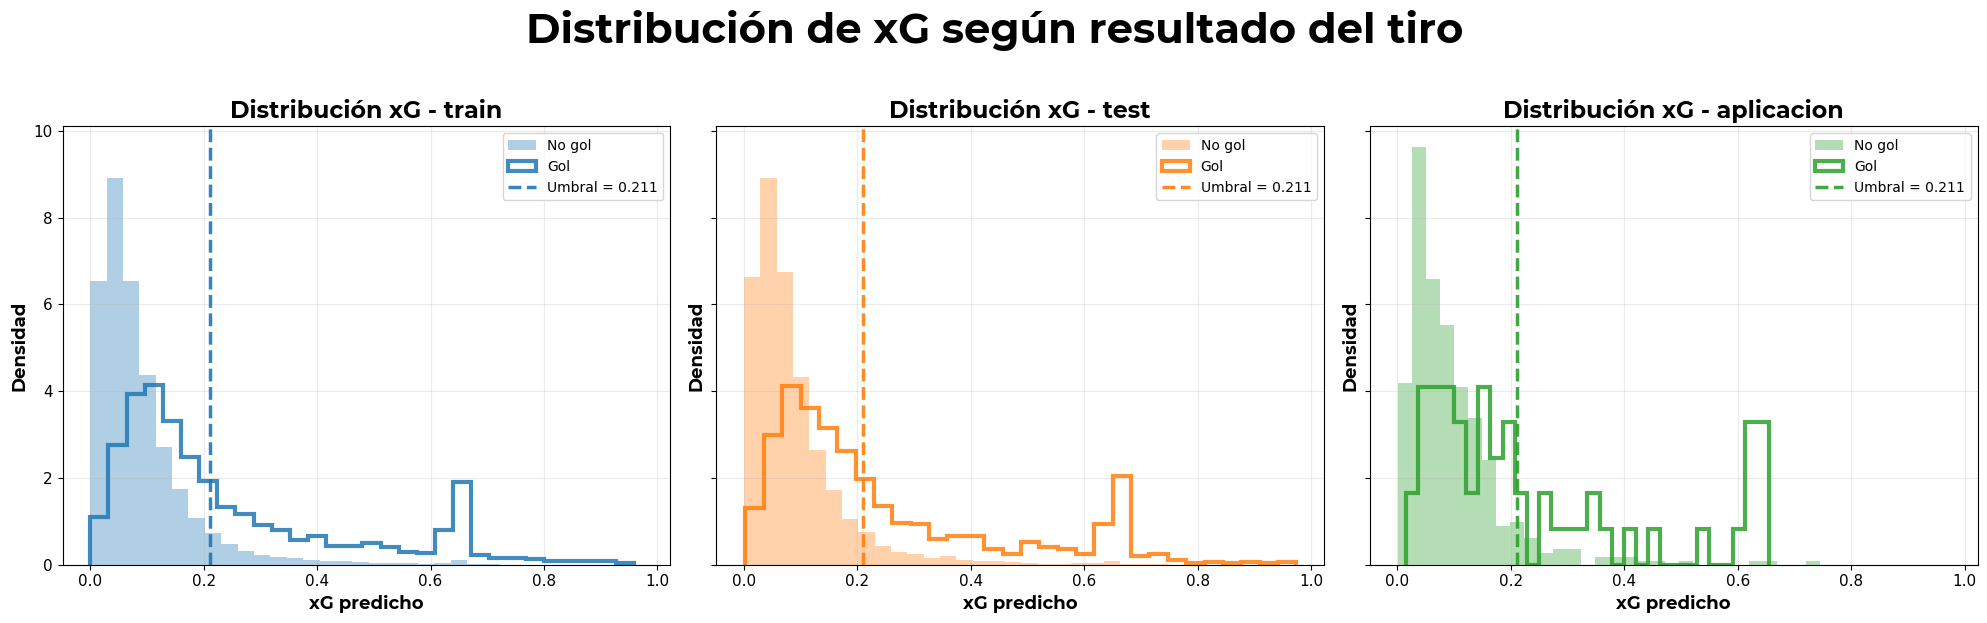

In [25]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharex=True,
    sharey=True)

for i, nombre_dataset in enumerate(datasets_validacion.keys()):

    contenido = datasets_validacion[nombre_dataset]

    y_real = contenido["y"].reset_index(drop=True)
    probabilidad = pd.Series(contenido["prob"]).reset_index(drop=True)

    df_distribucion = pd.DataFrame()
    df_distribucion["gol"] = y_real
    df_distribucion["xg"] = probabilidad

    xg_no_gol = df_distribucion[
        df_distribucion["gol"] == 0
    ]["xg"]

    xg_gol = df_distribucion[
        df_distribucion["gol"] == 1
    ]["xg"]

    ax = axes[i]

    ax.hist(
        xg_no_gol,
        bins=30,
        density=True,
        alpha=0.35,
        color=lista_colores[i],
        label="No gol")

    ax.hist(
        xg_gol,
        bins=30,
        density=True,
        alpha=0.85,
        color=lista_colores[i],
        histtype="step",
        linewidth=3,
        label="Gol")

    ax.axvline(
        umbral,
        linestyle="--",
        linewidth=2.5,
        color=lista_colores[i],
        alpha=0.90,
        label="Umbral = " + str(round(umbral, 3)))

    ax.set_title(
        "Distribución xG - " + nombre_dataset,
        fontsize=17,
        fontname="Montserrat",
        fontweight="bold")

    ax.set_xlabel(
        "xG predicho",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold")

    ax.set_ylabel(
        "Densidad",
        fontsize=13,
        fontname="Montserrat",
        fontweight="bold")

    ax.tick_params(axis="both", labelsize=11)

    ax.legend(
        fontsize=10,
        frameon=True)

    ax.grid(alpha=0.25)

plt.suptitle(
    "Distribución de xG según resultado del tiro",
    fontsize=30,
    fontname="Montserrat",
    fontweight="bold",
    y=1.03)

plt.tight_layout()
plt.show()

## • Coeficientes e importancia

In [26]:
if not df_coeficientes_modelo.empty:
    df_coeficientes_modelo

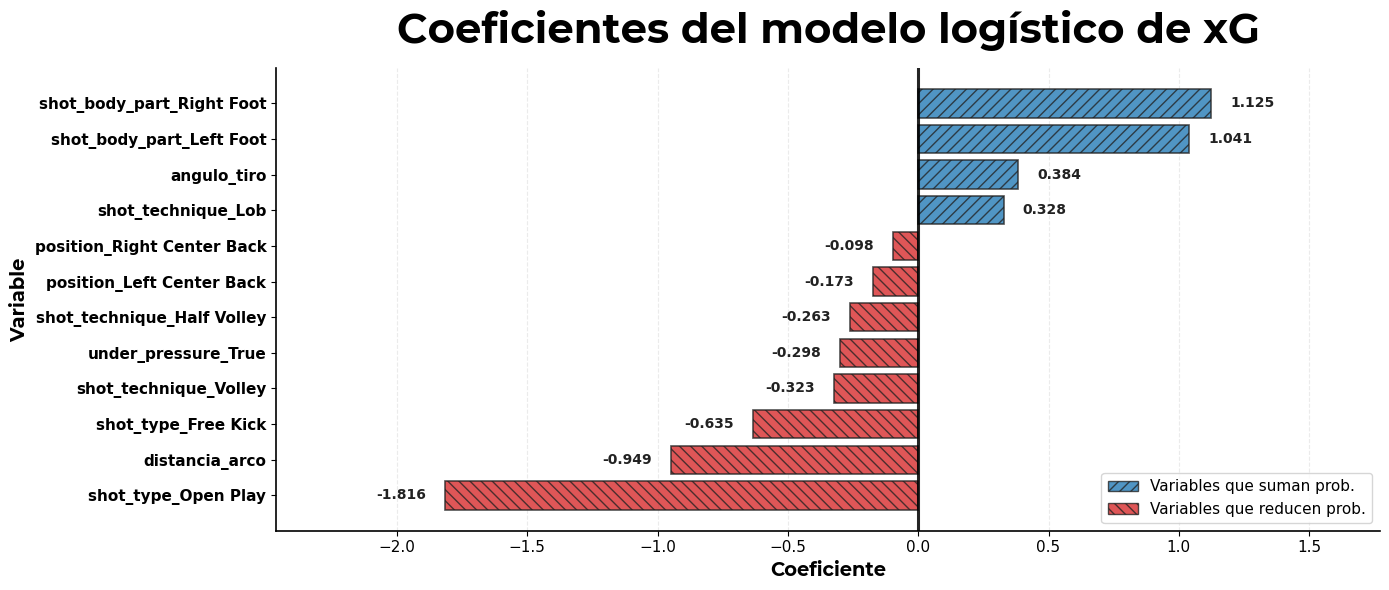

In [28]:
if not df_coeficientes_modelo.empty:

    df_coef_grafico = df_coeficientes_modelo.sort_values(
        "coeficiente",
        ascending=True).copy()

    colores = []
    tramados = []

    for valor in df_coef_grafico["coeficiente"]:
        if valor >= 0:
            colores.append("tab:blue")
            tramados.append("///")
        else:
            colores.append("tab:red")
            tramados.append("\\\\\\")
    
    fig, ax = plt.subplots(figsize=(14, 6))

    barras = ax.barh(
        df_coef_grafico["variable"],
        df_coef_grafico["coeficiente"],
        color=colores,
        alpha=0.78,
        edgecolor="#222222",
        linewidth=1.2)

    for barra, tramado in zip(barras, tramados):
        barra.set_hatch(tramado)

    ax.axvline(
        0,
        color="black",
        linewidth=2.2,
        alpha=0.85)

    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.8,
        alpha=0.25)

    ax.set_axisbelow(True)

    ax.set_title(
        "Coeficientes del modelo logístico de xG",
        fontsize=30,
        fontname="Montserrat",
        fontweight="bold",
        pad=18)

    ax.set_xlabel(
        "Coeficiente",
        fontsize=14,
        fontname="Montserrat",
        fontweight="bold")

    ax.set_ylabel(
        "Variable",
        fontsize=14,
        fontname="Montserrat",
        fontweight="bold")

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    for etiqueta in ax.get_yticklabels():
        etiqueta.set_fontweight("bold")

    valor_minimo = df_coef_grafico["coeficiente"].min()
    valor_maximo = df_coef_grafico["coeficiente"].max()

    rango = valor_maximo - valor_minimo
    margen = rango * 0.22

    ax.set_xlim(valor_minimo - margen,valor_maximo + margen)

    desplazamiento = rango * 0.025

    for barra in barras:
        ancho = barra.get_width()
        y = barra.get_y() + barra.get_height() / 2

        if ancho >= 0:
            ax.text(
                ancho + desplazamiento,
                y,
                str(round(ancho, 3)),
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold",
                color="#222222")
        else:
            ax.text(
                ancho - desplazamiento,
                y,
                str(round(ancho, 3)),
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold",
                color="#222222")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    positivo_patch = plt.Rectangle( (0, 0), 1, 1, facecolor="tab:blue", edgecolor="#222222", hatch="///", alpha=0.78, label="Variables que suman prob.")

    negativo_patch = plt.Rectangle( (0, 0), 1, 1, facecolor="tab:red", edgecolor="#222222", hatch="\\\\\\", alpha=0.78, label="Variables que reducen prob.")

    ax.legend(
        handles=[positivo_patch, negativo_patch],
        loc="lower right",
        fontsize=11,
        frameon=True)

    plt.tight_layout()
    plt.show()

In [29]:
if not df_importancia.empty:
    df_importancia

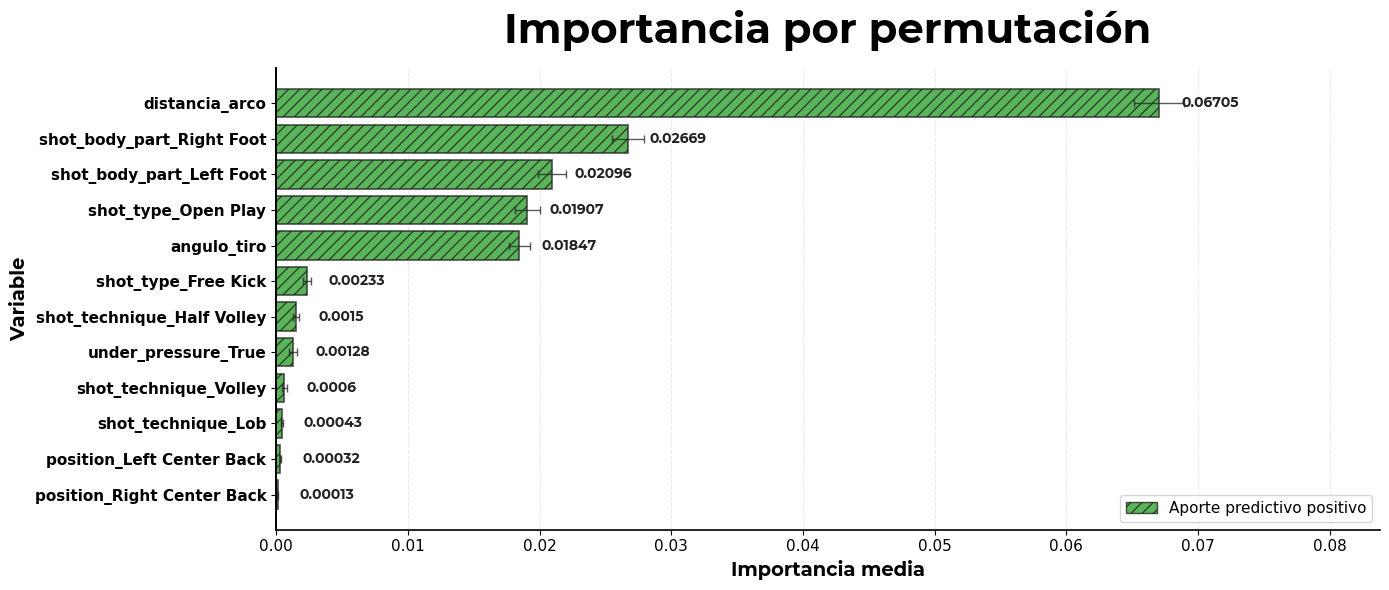

In [30]:
if not df_importancia.empty:

    df_importancia_grafico = df_importancia.sort_values(
        "importancia_media",
        ascending=True
    ).copy()

    colores = []
    tramados = []

    for valor in df_importancia_grafico["importancia_media"]:
        if valor >= 0:
            colores.append("tab:green")
            tramados.append("///")
        else:
            colores.append("tab:red")
            tramados.append("\\\\\\")

    fig, ax = plt.subplots(figsize=(14, 6))

    barras = ax.barh(
        df_importancia_grafico["variable"],
        df_importancia_grafico["importancia_media"],
        color=colores,
        alpha=0.78,
        edgecolor="#222222",
        linewidth=1.2
    )

    for barra, tramado in zip(barras, tramados):
        barra.set_hatch(tramado)

    if "importancia_std" in df_importancia_grafico.columns:
        ax.errorbar(
            df_importancia_grafico["importancia_media"],
            df_importancia_grafico["variable"],
            xerr=df_importancia_grafico["importancia_std"],
            fmt="none",
            ecolor="#222222",
            elinewidth=1,
            capsize=3,
            alpha=0.75
        )

    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.8,
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.set_title(
        "Importancia por permutación",
        fontsize=30,
        fontname="Montserrat",
        fontweight="bold",
        pad=18
    )

    ax.set_xlabel(
        "Importancia media",
        fontsize=14,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Variable",
        fontsize=14,
        fontname="Montserrat",
        fontweight="bold"
    )

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    for etiqueta in ax.get_yticklabels():
        etiqueta.set_fontweight("bold")

    valor_maximo = df_importancia_grafico["importancia_media"].max()
    margen_derecho = valor_maximo * 0.25

    ax.set_xlim(
        0,
        valor_maximo + margen_derecho
    )

    desplazamiento = valor_maximo * 0.025

    for barra in barras:
        ancho = barra.get_width()
        y = barra.get_y() + barra.get_height() / 2

        ax.text(
            ancho + desplazamiento,
            y,
            str(round(ancho, 5)),
            va="center",
            ha="left",
            fontsize=10,
            fontname="Montserrat",
            fontweight="bold",
            color="#222222"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.2)

    importancia_patch = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="tab:green",
        edgecolor="#222222",
        hatch="///",
        alpha=0.78,
        label="Aporte predictivo positivo"
    )

    ax.legend(
        handles=[importancia_patch],
        loc="lower right",
        fontsize=11,
        frameon=True
    )

    plt.tight_layout()
    plt.show()

## • Guardar tablas de validación

In [31]:
df_metricas_prob.to_csv(ruta_processed / "validacion_metricas_prob_xg_12vars.csv",index=False)

df_metricas_umbral.to_csv(ruta_processed / "validacion_metricas_umbral_operativo_xg_12vars.csv",index=False)

df_resumen_ks.to_csv(ruta_processed / "validacion_ks_xg_12vars.csv",index=False)

df_calibracion_resumen.to_csv(ruta_processed / "validacion_calibracion_deciles_xg_12vars.csv",index=False)

print("Guardado ok.")

Guardado ok.
